In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()

In [3]:
idx_A = np.nonzero(["_A_" in key for key in keys])
df = hdf.get(keys[idx_A[0][0]])

In [3]:
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

Feature processing plan:
- "Charge depleting cycle",
    - has 10 minute repeats of power control
    - split into 10 minute windows (every 600 rows exactly)
    - for each window, extract final 2 minutes [:-120] for held out test set input
    - extract 5 random 120s windows from the first 8 minutes for training set input
    - target is C/3 discharge capacity
- "Charge sustaining cycle",
    - last 30 minutes pull out for held out test set input
    - first 1.5 hours, pull out 5 random 30 minute segments
- 'Rate test C/2 cycle charge CC',
    - grab 10x random 15 minute windows
- 'PsRP 1 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'PsRP 2 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'Rate test 1C cycle charge CC',
    - grab 10x random 8 minute windows
- 'PsRP 1 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows
- 'PsRP 2 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows

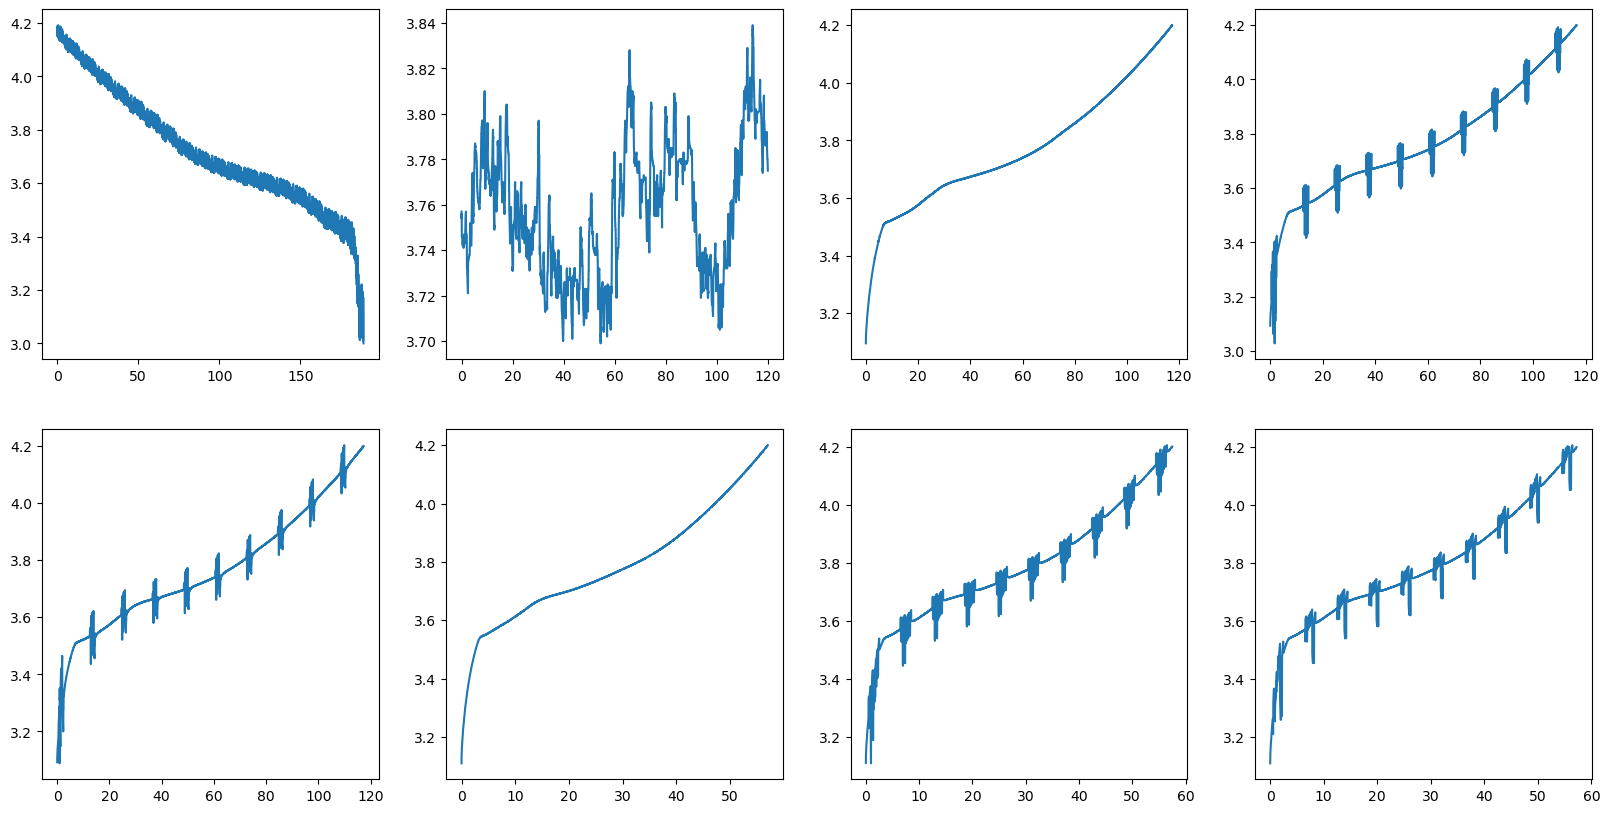

In [5]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])

To use the charge depleting cycle, we have to use chop it up into repeating 10 minute sections:

In [7]:
# get 10 min segments from the charge sustaining cycle
def get_10_min_segments(df):
    t_length = 599 # for whatever reason, the sequence is 599 seconds long, not 600
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = 599
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == t_length:
            df_segments.append(_df_segment)
        elif len(_df_segment) > t_length:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == t_length:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
        t_start += t_length
        t_end += t_length
    return df_segments

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

# For a measurement, return collated data from the charge-depleting cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge depleting cycle" in seg_desc for seg_desc in df["Segment Description"]
]

#split the repeating charge depleting cycles into individual 10 min cycles
dfs = get_10_min_segments(df[is_cycle])
time = dfs[0]['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)

for i, t in enumerate(time):
    if i == 0:
        # columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        # columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

for i, df_seg in enumerate(dfs):
    if i == 0:
        soc_mean = df_seg.SOC.to_numpy().mean()
        soc_initial = df_seg.SOC.to_numpy()[0]
        soc_final = df_seg.SOC.to_numpy()[-1]
        temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
        voltage = df_seg[col_voltage].to_numpy()
        current = df_seg["Current, A"].to_numpy()
        power = df_seg["Power, W"].to_numpy()
    else:
        soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
        soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
        soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
        temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
        voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
        current = np.vstack((current, df_seg["Current, A"].to_numpy()))
        power = np.vstack((power, df_seg["Power, W"].to_numpy()))

out = np.hstack((temperature, soc_mean, soc_initial, soc_final, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] + columns_voltage + columns_current + columns_power)

df_out = pd.DataFrame(out, columns=columns)
df_out

removed extra data in segment starting at 4193 seconds
removed extra data in segment starting at 4792 seconds
removed extra data in segment starting at 5391 seconds


,temperature,soc_mean,soc_initial,soc_final,voltage_ 0.0s,voltage_ 1.0s,voltage_ 2.0s,voltage_ 3.0s,voltage_ 4.0s,voltage_ 5.0s,...,power_589.0s,power_590.0s,power_591.0s,power_592.0s,power_593.0s,power_594.0s,power_595.0s,power_596.0s,power_597.0s,power_598.0s
0,29.500000,0.974328,1.000000,0.952973,4.188,4.188,4.188,4.188,4.188,4.187,...,60.4,58.6,35.4,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
1,29.500000,0.926881,0.952969,0.905190,4.119,4.119,4.119,4.119,4.119,4.118,...,60.2,58.4,35.4,1.2,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
2,29.516694,0.878705,0.905186,0.856690,4.059,4.059,4.059,4.059,4.059,4.058,...,60.4,58.4,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
3,29.717863,0.829822,0.856686,0.807490,4.002,4.002,4.002,4.002,4.002,4.002,...,60.2,58.4,35.4,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
4,29.922371,0.780246,0.807486,0.757605,3.949,3.949,3.949,3.949,3.949,3.948,...,60.4,58.6,35.4,1.4,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
5,29.995826,0.729994,0.757601,0.707047,3.898,3.898,3.898,3.898,3.898,3.897,...,60.4,58.4,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
6,29.999165,0.679070,0.707043,0.655817,3.850,3.850,3.850,3.850,3.850,3.849,...,60.4,58.4,35.5,1.2,-3.9,-3.4,-3.4,-3.4,-3.4,-3.4
7,29.994157,0.627477,0.655813,0.603900,3.801,3.801,3.801,3.801,3.802,3.800,...,60.2,58.6,35.5,1.4,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
8,29.843072,0.575172,0.603896,0.551321,3.745,3.745,3.745,3.745,3.745,3.744,...,60.4,58.6,35.5,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
9,29.526711,0.522326,0.551317,0.498266,3.705,3.705,3.705,3.705,3.705,3.704,...,60.2,58.6,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6


There are occasional issues, like large gaps or extraneous data points in the cycle. These extra points can be discarded with no issue, and only the 10 minute section with the large gap has to be discarded. 

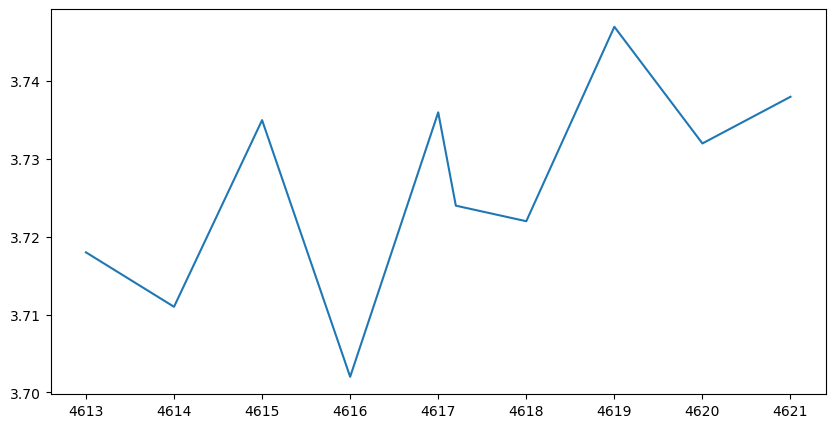

In [ ]:
# Some datasets have extra data points in the cycle

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

df[df['Segment Description'].str.contains('Charge depleting cycle')]

time = df[df['Segment Description'].str.contains('Charge depleting cycle')]['Segment Time, S']

fig, ax = plt.subplots(figsize=(10, 5))
section = df[(df['Total Time, S'] >=369725.6) & (df['Total Time, S'] <= 369733.6)]
ax.plot(section['Segment Time, S'], section[col_voltage])
# ax.plot(range(len(time)), time / 60)

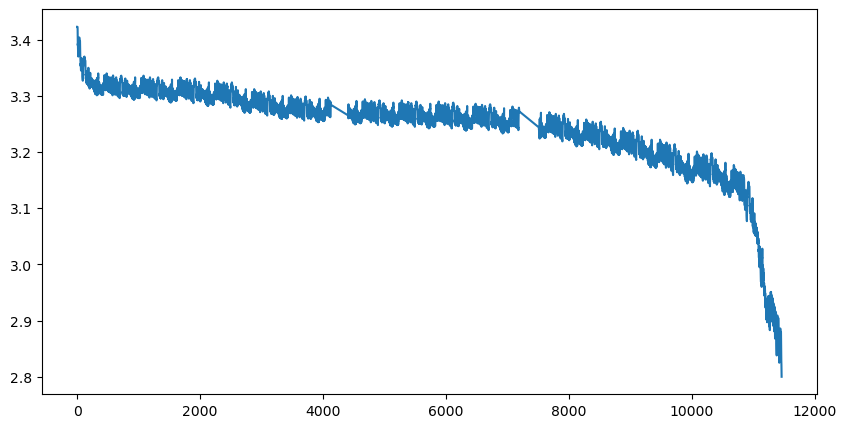

In [9]:
df = hdf.get('/D/data_240820_ReCellML_A123_cell27_charac_30oC')

df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'], df[col_voltage])

Closer look at the missing sections

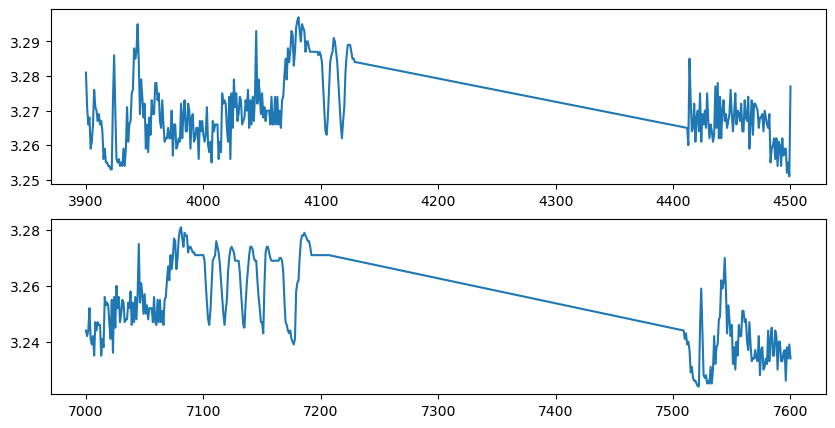

In [10]:
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()
df1 = df[df['Segment Time, S'].between(3900, 4500)]
df2 = df[df['Segment Time, S'].between(7000, 7600)]
ax[0].plot(df1['Segment Time, S'], df1[col_voltage])
ax[1].plot(df2['Segment Time, S'], df2[col_voltage])

Sanity check to verify that the actual 10 minute sections line up the way that they should between different cells. 

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3056413589.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 4)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3056413589.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first['cell_type'] = [id[0] for id in df_first['cell_id']]


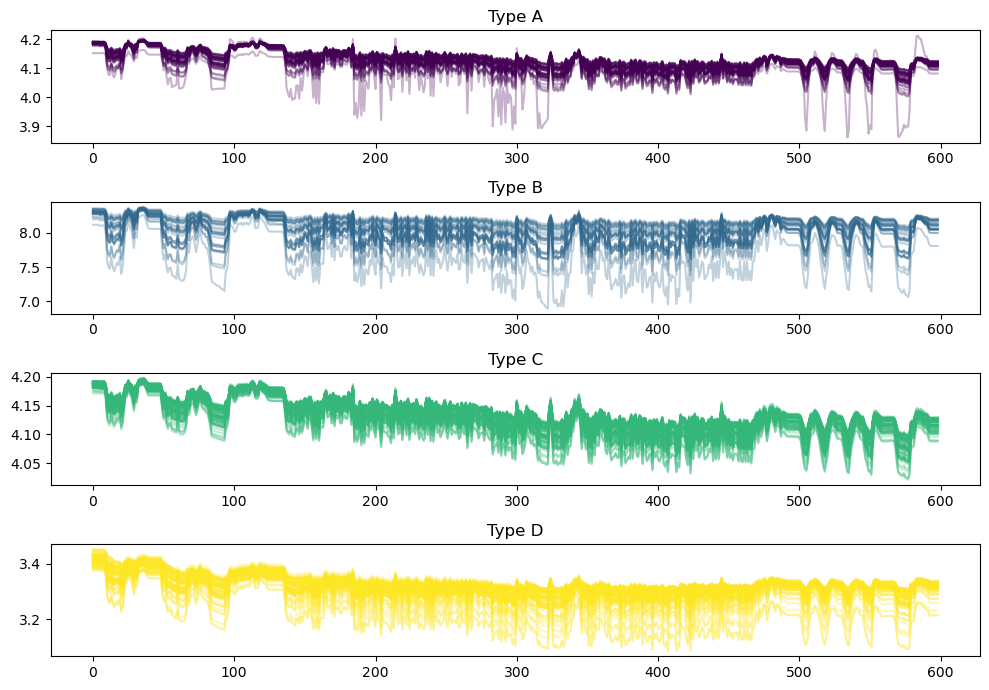

In [11]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv')
df_first = df[df['soc_initial'] == 1.0]

cmap = cm.get_cmap('viridis', 4)

df_first['cell_type'] = [id[0] for id in df_first['cell_id']]

type_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3
}
fig, ax = plt.subplots(4, 1, figsize=(10, 7))
for i, row in df_first.iterrows():
    ax[type_map[row.cell_type]].plot(range(599), row.filter(regex='^voltage'), alpha=0.3, c = cmap(type_map[row.cell_type]))
# df_first
ax[0].set_title('Type A')
ax[1].set_title('Type B')
ax[2].set_title('Type C')
ax[3].set_title('Type D')

fig.tight_layout()

# ax = sns.relplot(data=df_first,x='Segment Time, T', y='', legend=False, alpha=0.3, col="cell_type", kind='line')

This graph is critical, it verifies that the ammount of time between repetitions is the same across all batteries of the same type. 

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3806608481.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A charge depleting cycle voltage profiles colored by SOC')

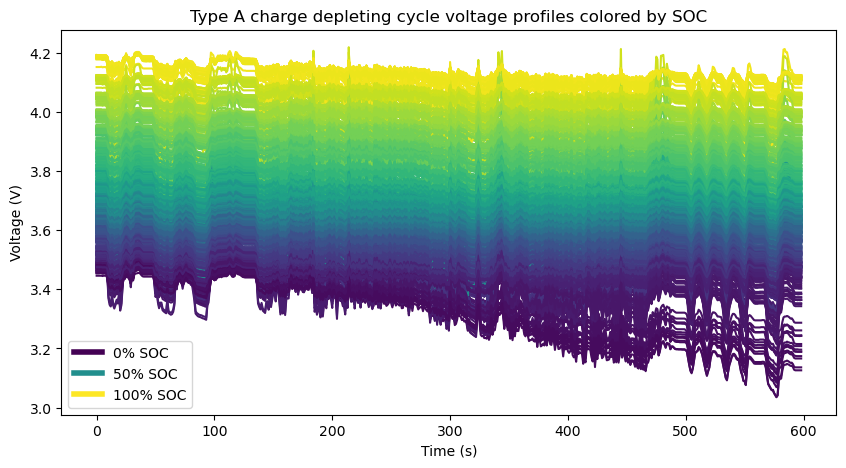

In [12]:
df_a = df[df['cell_id'].str.contains('A')]
cmap = cm.get_cmap('viridis', 100)
plt.figure(figsize=(10, 5))
for i, row in df_a.iterrows():
    plt.plot(range(599), row.filter(regex='^voltage'), alpha=1, c=cmap(row['soc_mean']))
    
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge depleting cycle voltage profiles colored by SOC')

Get Charge Cycles:

I want to create sections of the time series that include pseudo random pulses, but the pulses themselves are recorded at 1 sec resolution, while the charge cycle around it is every 5-10 seconds. I must then interpolate it to be every second, and this code is experimentation with diferent methods of doing that. 

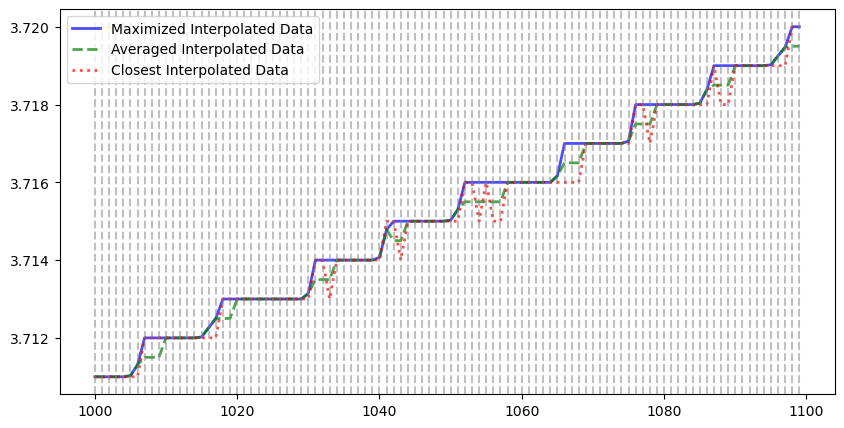

In [ ]:
df = hdf.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

key = "PsRP 1 1C diagnostic cycle charge"
cell_id_prefix = 'A_'
cell_id_num = '15'

# For a measurement, return collated data from the charge cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    key in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = retime(df[is_cycle])
# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']


columns = [
    "Voltage_",
    "Current_",
    "Power_",
    "SOC_",
    "Segment_Time_S_",
]
if df_seg.iloc[0]['Temperature A1, °C'] < 25:
    temp_category = '15C'
elif (df_seg.iloc[0]['Temperature A1, °C'] > 25) and (df_seg.iloc[0]['Temperature A1, °C'] <= 38):
    temp_category = '30C'
elif df_seg.iloc[0]['Temperature A1, °C'] > 38:
    temp_category = '45C'

for i, col in enumerate(columns):
    columns[i] = col + cell_id_prefix + "Cell" + cell_id_num +"_" + temp_category




# for i, t in enumerate(time):
#     if i == 0:
#         columns_soc = ["soc_%5.1fs" % (t)]
#         columns_voltage = ["voltage_%5.1fs" % (t)]
#         columns_current = ["current_%5.1fs" % (t)]
#         columns_power = ["power_%5.1fs" % (t)]
#     else:
#         columns_soc += ["soc_%5.1fs" % (t)]
#         columns_voltage += ["voltage_%5.1fs" % (t)]
#         columns_current += ["current_%5.1fs" % (t)]
#         columns_power += ["power_%5.1fs" % (t)]

# soc_mean = df_seg.SOC.to_numpy().mean()
# soc_initial = df_seg.SOC
# soc_final = df_seg.SOC.to_numpy()[-1]
soc = df_seg.SOC.to_numpy()
# temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()

out = np.vstack((soc, voltage, current, power, time))

def get_2_closest_cols(df_seg, target_time):
    times = df_seg['Segment Time, S'].to_numpy()
    diffs = np.abs(times - target_time)
    idx_sorted = np.argsort(diffs)
    return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

#interpolate the data at 1 second intervals
for i in range(time[len(time)-1].round().astype(int)):
    
    if i == 0:
        soc_interp = [soc[0]]
        voltage_interp = [voltage[0]]
        current_interp = [current[0]]
        power_interp = [power[0]]
        time_interp = [i]
        soc_interp_av = [soc[0]]
        voltage_interp_av = [voltage[0]]
        current_interp_av = [current[0]]
        power_interp_av = [power[0]]
        soc_interp_closest = [soc[0]]   
        voltage_interp_closest = [voltage[0]]
        current_interp_closest = [current[0]]
        power_interp_closest = [power[0]]
        continue

    time_interp += [i]

    # if the two closest points are already at 1 second intervals, just take the closest value
    seg_1, seg_2 = get_2_closest_cols(df_seg, i)
    time_1 = seg_1['Segment Time, S']
    time_2 = seg_2['Segment Time, S']

    #save the closer of the two points
    if time_2 < time_1:
        soc_interp_closest += [seg_2['SOC']]
        voltage_interp_closest += [seg_2[col_voltage]]
        current_interp_closest += [seg_2['Current, A']]
        power_interp_closest += [seg_2['Power, W']]
    else:
        soc_interp_closest += [seg_1['SOC']]
        voltage_interp_closest += [seg_1[col_voltage]]
        current_interp_closest += [seg_1['Current, A']]
        power_interp_closest += [seg_1['Power, W']]

    if (time_2 - time_1) == 1:
        if time_2 < time_1: #time 2 is the closest point
            soc_interp += [seg_2['SOC']]
            voltage_interp += [seg_2[col_voltage]] 
            current_interp += [seg_2['Current, A']]
            power_interp += [seg_2['Power, W']]
            soc_interp_av += [seg_2['SOC']]
            voltage_interp_av += [seg_2[col_voltage]]
            current_interp_av += [seg_2['Current, A']]
            power_interp_av += [seg_2['Power, W']]
        else:
            soc_interp += [seg_1['SOC']]
            voltage_interp += [seg_1[col_voltage]] 
            current_interp += [seg_1['Current, A']]
            power_interp += [seg_1['Power, W']]
            soc_interp_av += [seg_1['SOC']]
            voltage_interp_av += [seg_1[col_voltage]]
            current_interp_av += [seg_1['Current, A']]
            power_interp_av += [seg_1['Power, W']]
        continue

    #if the two points are within 0.3 seconds of each other, take the highest
    if (time_2 - time_1) < 0.3: 
        soc_interp += [max(seg_1['SOC'], seg_2['SOC'])]
        voltage_interp += [max(seg_1[col_voltage], seg_2[col_voltage])]
        current_interp += [max(seg_1['Current, A'], seg_2['Current, A'])]
        power_interp += [max(seg_1['Power, W'], seg_2['Power, W'])]

        soc_interp_av += [(seg_1['SOC'] + seg_2['SOC']) / 2]
        voltage_interp_av += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
        current_interp_av += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
        power_interp_av += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
        continue

    #finally, if the two closest points are not at 1 second intervals, interpolate with two closest points
    # soc_interp += [np.interp(i, (time_1, time_2), (seg_1['SOC'], seg_2['SOC']))]
    # voltage_interp += [np.interp(i, (time_1, time_2), (seg_1[col_voltage], seg_2[col_voltage]))]
    # current_interp += [np.interp(i, (time_1, time_2), (seg_1['Current, A'], seg_2['Current, A']))]
    # power_interp += [np.interp(i, (time_1, time_2), (seg_1['Power, W'], seg_2['Power, W']))]

    soc_interp += [np.interp(i, time, soc)]
    voltage_interp += [np.interp(i, time, voltage)]
    current_interp += [np.interp(i, time, current)]
    power_interp += [np.interp(i, time, power)]

    soc_interp_av += [np.interp(i, time, soc)]
    voltage_interp_av += [np.interp(i, time, voltage)]
    current_interp_av += [np.interp(i, time, current)]
    power_interp_av += [np.interp(i, time, power)]


out_interp = np.vstack((soc_interp, voltage_interp, current_interp, power_interp, time_interp))
out_interp_av = np.vstack((soc_interp_av, voltage_interp_av, current_interp_av, power_interp_av, time_interp))
out_interp_closest = np.vstack((soc_interp_closest, voltage_interp_closest, current_interp_closest, power_interp_closest, time_interp))
# out
# columns = (["temperature"] + columns_soc + columns_voltage + columns_current + columns_power)
df_out = pd.DataFrame(out_interp, index=columns)
# df_out

df_out_av = pd.DataFrame(out_interp_av, index=columns)  
df_out_closest = pd.DataFrame(out_interp_closest, index=columns)

offset = 1000
length = 100
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_out.iloc[-1][offset:offset+length], df_out.iloc[1][offset:offset+length], label='Maximized Interpolated Data', color='blue', alpha=0.7, linewidth=2)
ax.plot(df_out_av.iloc[-1][offset:offset+length], df_out_av.iloc[1][offset:offset+length], label='Averaged Interpolated Data', color='green', alpha=0.7, linewidth=2, linestyle='--')
ax.plot(df_out_closest.iloc[-1][offset:offset+length], df_out_closest.iloc[1][offset:offset+length], label='Closest Interpolated Data', color='red', alpha=0.7, linewidth=2, linestyle=':')
for point in df_out.iloc[-1][offset:offset+length]:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5) 

#write dfs out to csv
df_out.to_csv('df_out.csv')
df_out_av.to_csv('df_out_av.csv')
df_out_closest.to_csv('df_out_closest.csv')

plt.legend()


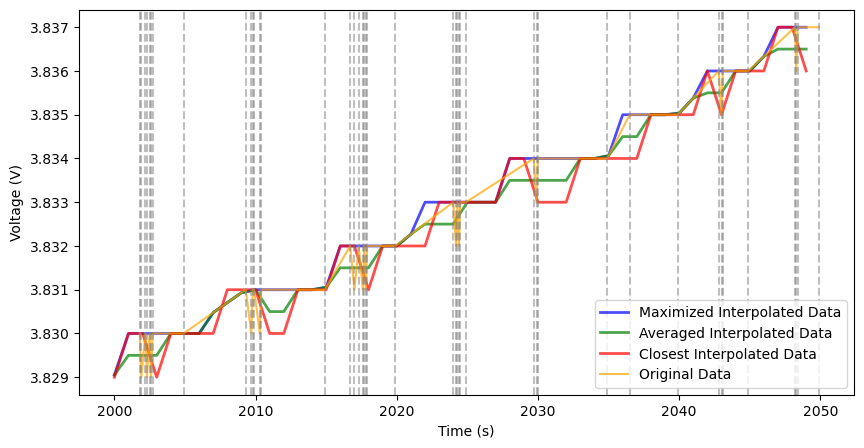

In [ ]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
df = df.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

df = df[df['Segment Description'].str.contains('PsRP 1 1C diagnostic cycle charge')]
df = retime(df)

offset = 2000
length = 50
df = df[df['Segment Time, S'].between(offset, offset+length)]

_time = df['Segment Time, S'].values
_data = df['Voltage, V'].values

#compare the interpolated data to the original data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_out.iloc[-1][offset:offset+length], df_out.iloc[1][offset:offset+length], label='Maximized Interpolated Data', color='blue', alpha=0.7, linewidth=2)
ax.plot(df_out_av.iloc[-1][offset:offset+length], df_out_av.iloc[1][offset:offset+length], label='Averaged Interpolated Data', color='green', alpha=0.7, linewidth=2)
ax.plot(df_out_closest.iloc[-1][offset:offset+length], df_out_closest.iloc[1][offset:offset+length], label='Closest Interpolated Data', color='red', alpha=0.7, linewidth=2)
ax.plot(_time, _data, label='Original Data', color='orange', alpha=0.7)
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.legend()

Note here the vertical lines are when the equipment took measurements. Notice the discrepancy between the pulse and everything else. 

Text(0, 0.5, 'Voltage (V)')

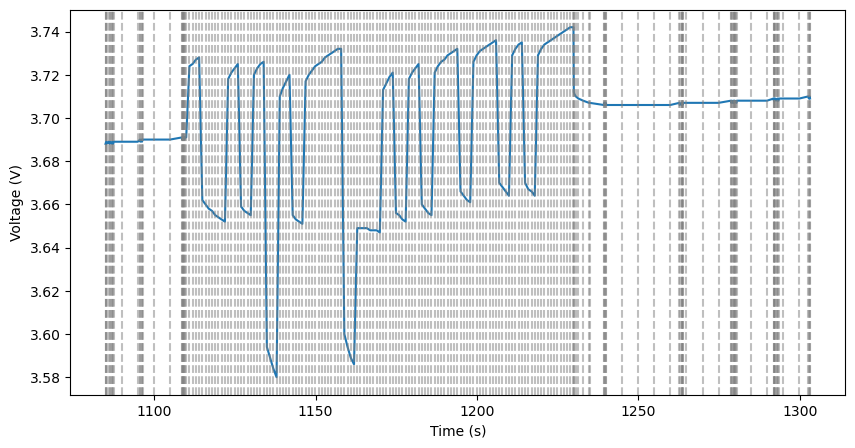

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

offset = 1050
_time = time_rows.iloc[0].iloc[offset:offset+200]
_data = voltage_rows.iloc[0].iloc[offset:offset+200]
ax.plot(_time, _data)   
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

Verify for each type of cell that the 10 minute chunks do actually work for the charge depleting cycle

Notice here that type C and D cells don't line up perfectly over time. There is a subtle shift overtime as the SOC decreases. This is because it isn't actually a perfect 600 rows, type A and B repeat every 599 seconds and type C and D repeat every 600. 

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19628\2924995837.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


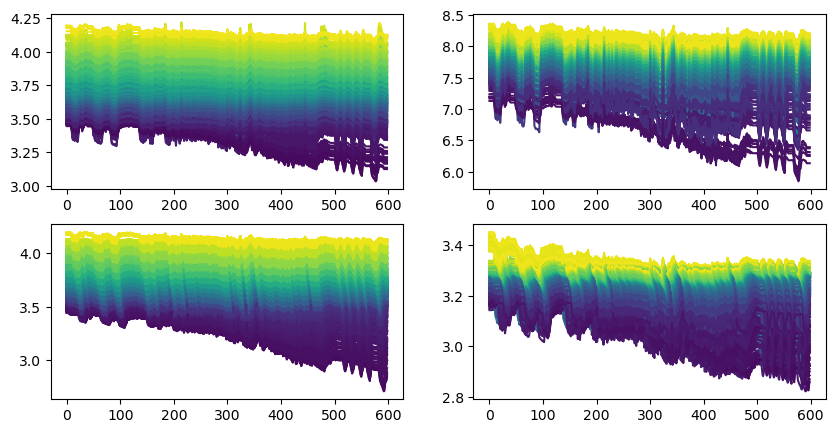

In [ ]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv', index_col=0)
df_d = df[df['cell_id'].str.contains('D')]
cmap = cm.get_cmap('viridis', 100)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax = ax.flatten()
for i, row in df[df['cell_id'].str.contains('A')].iterrows():
    ax[0].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('B')].iterrows():
    ax[1].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('C')].iterrows():
    ax[2].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('D')].iterrows():
    ax[3].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))


I was running into trouble processing the type D cells. I tracked this down to the cycle length; the particularly terrible type d cells would last long enough for my code to get even 1 section out of it. 

In [1]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = [key for key in df.keys() if '/C/' in key]
print(keys)


fig, ax = plt.subplots(2, 4, figsize=(15, 5))
ax = ax.flatten()

segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

for df in [hdf.get(key) for key in keys]:
    for i, segment in enumerate(segments_of_interest):
        df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
        df_segment = retime(df_segment)
        ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'], c=cmap(df_segment['Temperature A1, °C'].iloc[0]/45), alpha=0.7)


NameError: name 'pd' is not defined

 Notice the wide variation among cycle lengths.

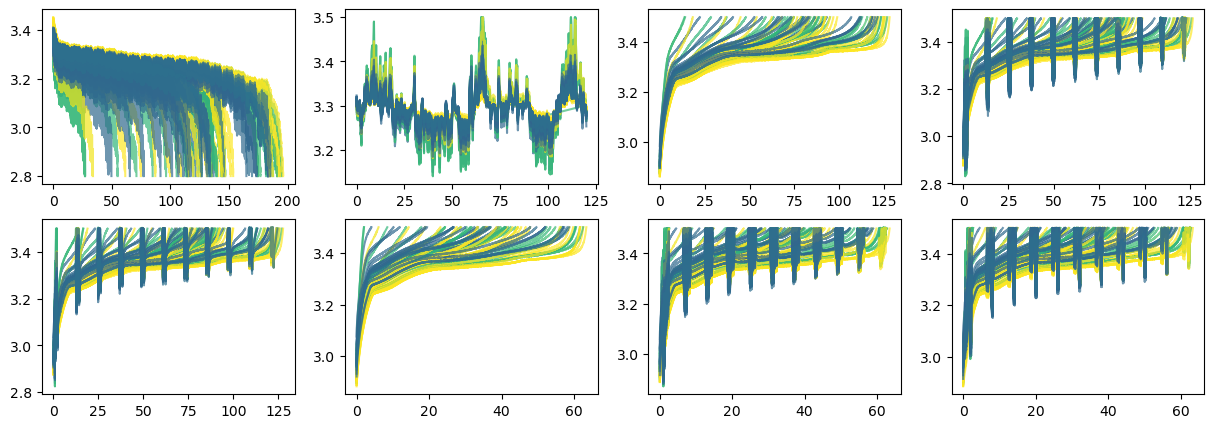

In [ ]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = [key for key in df.keys() if '/D/' in key]
fig, ax = plt.subplots(2, 4, figsize=(15, 5))
ax = ax.flatten()
for df in [hdf.get(key) for key in keys]:
    for i, segment in enumerate(segments_of_interest):
        df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
        df_segment = retime(df_segment)
        ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'], c=cmap(df_segment['Temperature A1, °C'].iloc[0]/45), alpha=0.7)

I also noticed that SOC prediction was running into some issues. This was because the actual SOC was recorded as negative for only some of the batteries. 

Notice here the bifrication of the SOC in the type C cells in particular, and the entirely negative SOC for the type D cells.

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_44328\2083365675.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


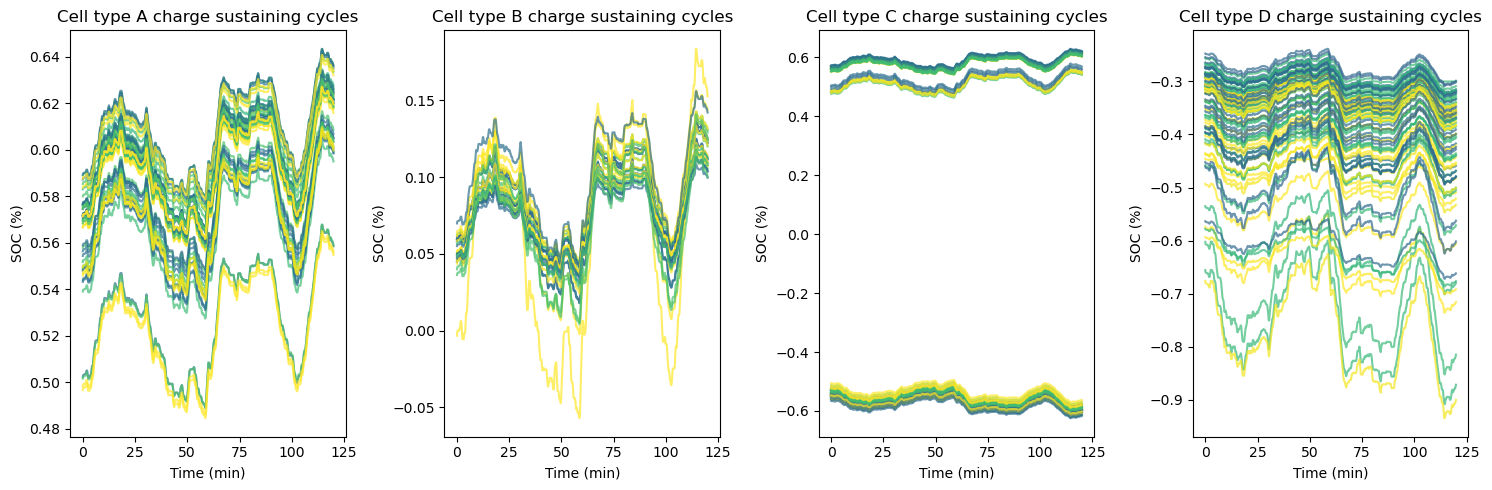

In [11]:
cmap = cm.get_cmap('viridis', 100)
cell_types = {
    'A':0, 
    'B':1, 
    'C':2,
    'D':3
}

keys = hdf2.keys()

fig, ax = plt.subplots(1,4,figsize=(15,5))

for key in keys:
    df = hdf2.get(key)
    df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]
    ax[cell_types[key[1]]].plot(df['Segment Time, S']/60, df['SOC'], c=cmap(df['Temperature A1, °C'].iloc[0]/45), alpha=0.7)
for cell in cell_types:
    ax[cell_types[cell]].set_title(f'Cell type {cell} charge sustaining cycles')
    ax[cell_types[cell]].set_xlabel('Time (min)')
    ax[cell_types[cell]].set_ylabel('SOC (%)')

fig.tight_layout()